# معالجة البيانات

Soft Drinks & Juices,المشروبات الغازية والعصائر
Water,مياه
"Tea, Coffee & Hot Drinks / Tea and Coffee",الشاي، القهوة والمشروبات الساخنة
Dairy & Eggs,الألبان والبيض
Vegetables & Fruits / Vegetables & Herbs / Fruits,الخضروات، الفواكه والأعشاب
Beef & Processed Meat / Beef & Lamb Meat,لحوم البقر، الغنم واللحوم المصنعة
Poultry,الدواجن
"Rice, Pasta & Pulses",الأرز، المكرونة والبقوليات
"Tins, Jars & Packets",المعلبات والبرطمانات والطرود
Bakery,المخبوزات
Biscuits & Cakes,البسكويت والكيك
Chips & Crackers / Chips & crackers,الشيبس والمقرمشات
"Chocolates, Sweets & Desserts / Sweets & Desserts",الشوكولاتة، الحلويات والتحلية
"Nuts, Dates & Dried Fruits",المكسرات، التمور والفواكه المجففة
Breakfast Cereals & Bars,حبوب الإفطار وألواح الطاقة
Cooking Ingredients,مكونات الطبخ
Sugar & Home Baking,السكر ومستلزمات الخبز المنزلي
"Sauces, Dressings & Condiments",الصلصات، التتبيلات والمقبلات
"Condiments, Dressings & Marinades",التوابل، التتبيلات والنقعات
"Jams, Spreads & Syrups",المربى، دهون الخبز (السبريد) والشراب المركز
"Personal care, skin & body care",العناية الشخصية، البشرة والجسم
"Hair, Shower, Bath & Soap",العناية بالشعر، الاستحمام والصابون
Baby Care,العناية بالطفل
Cleaning Supplies,أدوات التنظيف
Laundry & Detergents,الغسيل والمنظفات
Disposables & Napkins,المنتجات الاستهلاكية والمناديل
Home Appliances,الأجهزة المنزلية
Mobile & Tablets,الهواتف والأجهزة اللوحية
Furniture,الأثاث
Stationary,القرطاسية والأدوات المكتبية
Party supplies and gifts,مستلزمات الحفلات والهدايا

In [11]:
pip show numpy

Name: numpy
Version: 2.4.6
Summary: Fundamental package for array computing in Python
Home-page: https://numpy.org
Author: Travis E. Oliphant et al.
Author-email: 
License-Expression: BSD-3-Clause AND 0BSD AND MIT AND Zlib AND CC0-1.0
Location: C:\Users\aa\anaconda3\Lib\site-packages
Requires: 
Required-by: accelerate, altair, astropy, bitsandbytes, bokeh, Bottleneck, chromadb, contourpy, datasets, datashader, evaluate, featuretools, gensim, h5py, holoviews, hvplot, imagecodecs, imageio, imbalanced-learn, langchain-community, lightgbm, matplotlib, mealpy, mkl-fft, mkl-random, ml-dtypes, mlxtend, numba, numexpr, onnxruntime, opencv-python, opfunu, optuna, pandas, patsy, peft, permetrics, pydeck, pyerfa, pywavelets, rouge_score, scikit-image, scikit-learn, scipy, seaborn, statsmodels, streamlit, tables, tensorboard, tifffile, torchmetrics, torchvision, transformers, woodwork, xanfis, xarray, xgboost, yfinance
Note: you may need to restart the kernel to use updated packages.


In [13]:
import sys
print(sys.version)

3.12.4 | packaged by Anaconda, Inc. | (main, Jun 18 2024, 15:03:56) [MSC v.1929 64 bit (AMD64)]


In [1]:
import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import RandomOverSampler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
from sklearn.svm import LinearSVC
from sklearn.multiclass import OneVsRestClassifier

In [2]:
train = pd.read_csv("train.csv")
val = pd.read_csv("val.csv")
test = pd.read_csv("test.csv")
print(f"Train size: {len(train)}")
print(f"Val size: {len(val)}")
print(f"Test size: {len(test)}")

Train size: 7000
Val size: 1500
Test size: 1500


In [5]:
datasets = [train, val, test]

for i in range(len(datasets)):
    datasets[i] = datasets[i][datasets[i]['class'] != 'Party supplies and gifts']

train, val, test = datasets

print(f"Train size: {len(train)}")
print(f"Val size: {len(val)}")
print(f"Test size: {len(test)}")

Train size: 6999
Val size: 1500
Test size: 1500


In [7]:
category_map = {
    # Beverages
    'Soft Drinks & Juices': 'Beverages', 'Water': 'Beverages', 
    'Tea, Coffee & Hot Drinks': 'Beverages', 'Tea and Coffee': 'Beverages',
    
    # Bakery & Breakfast
    'Bakery': 'Bakery & Breakfast', 'Biscuits & Cakes': 'Bakery & Breakfast', 
    'Breakfast Cereals & Bars': 'Bakery & Breakfast', 'Sugar & Home Baking': 'Bakery & Breakfast',
    
    # Snacks & Sweets
    'Chips & Crackers': 'Snacks & Sweets', 'Chips & crackers': 'Snacks & Sweets', 
    'Chocolates, Sweets & Desserts': 'Snacks & Sweets', 'Sweets & Desserts': 'Snacks & Sweets',
    
    # Fruits & Vegetables
    'Vegetables & Fruits': 'Fruits & Vegetables', 'Vegetables & Herbs': 'Fruits & Vegetables', 'Fruits': 'Fruits & Vegetables',
    
    # Meat & Poultry
    'Beef & Processed Meat': 'Meat & Poultry', 'Beef & Lamb Meat': 'Meat & Poultry', 'Poultry': 'Meat & Poultry',
    
    # Dairy & Eggs
    'Dairy & Eggs': 'Dairy & Eggs',
    
    # Pantry & Cooking Ingredients
    'Cooking Ingredients': 'Pantry & Cooking Ingredients', 'Rice, Pasta & Pulses': 'Pantry & Cooking Ingredients', 
    'Tins, Jars & Packets': 'Pantry & Cooking Ingredients', 'Sauces, Dressings & Condiments': 'Pantry & Cooking Ingredients', 
    'Condiments, Dressings & Marinades': 'Pantry & Cooking Ingredients', 'Jams, Spreads & Syrups': 'Pantry & Cooking Ingredients',
    'Nuts, Dates & Dried Fruits': 'Pantry & Cooking Ingredients',
    
    # Household & Cleaning
    'Cleaning Supplies': 'Household & Cleaning', 'Laundry & Detergents': 'Household & Cleaning', 'Disposables & Napkins': 'Household & Cleaning',
    
    # Personal Care
    'Personal care, skin & body care': 'Personal Care', 'Hair, Shower, Bath & Soap': 'Personal Care',
    
    # Baby Products
    'Baby Care': 'Baby Products',
    
    # Electronics
    'Mobile & Tablets': 'Electronics', 'Home Appliances': 'Electronics',
    
    # Home & Furniture
    'Furniture': 'Home & Furniture',
    
    # Office & Stationery
    'Stationary': 'Office & Stationery',
    
    # Party & Gifts
    #'Party supplies and gifts': 'Party & Gifts'
}

In [9]:
dataframes = [train, val, test]

for df in dataframes:
    df['class'] = df['class'].map(category_map).fillna(df['class'])

print(train['class'].unique())

['Beverages' 'Bakery & Breakfast' 'Snacks & Sweets' 'Home & Furniture'
 'Fruits & Vegetables' 'Meat & Poultry' 'Household & Cleaning'
 'Pantry & Cooking Ingredients' 'Dairy & Eggs' 'Personal Care' nan
 'Baby Products' 'Office & Stationery' 'Electronics']


In [11]:
Fast_Food = [
        "شاورما دجاج عربي", "شاورما لحم صاج", "ساندوتش صاروخ دجاج", "شاورما لحم دبل", 
        "شاورما بالجبنة السائلة", "ساندوتش كبدة إسكندراني", "ساندوتش سجق بدبس الرمان", 
        "حواوشي إسكندراني", "حواوشي بالجبن الموتزاريلا", "ساندوتش فلافل محشي", 
        "ساندوتش طعمية بالبيض", "ساندوتش بطاطس سوري بالثومية", "ساندوتش شيش طاووق صاج", 
        "ساندوتش كفتة مشوية", "ساندوتش زنجر سوبريم", "ساندوتش فاهيتا دجاج", 
        "ساندوتش مسحب حراق", "ساندوتش مقالي مشكل", "برجر حاشي عربي", "برجر دجاج بالخلطة الشرقية",
        "ساندوتش كبة مقلية", "ساندوتش عرايس لحم", "شاورما بخبز التورتيلا", "شاورما دجاج جامبو",
        "ساندوتش طحال", "ساندوتش مخ بانيه", "ساندوتش جمبري مقلي", "ساندوتش سمك فيليه",
        "شاورما لحم بالبقدونس والطحينة", "ساندوتش دجاج مشوي سبايسي", "ساندوتش برجر بيض",
        "ساندوتش فلافل سوبر", "ساندوتش باذنجان وبطاطس", "ساندوتش شكشوكة", "ساندوتش تونة بالمايونيز",
        "شاورما دجاج دايت", "ساندوتش كفتة دجاج", "ساندوتش كباب ميرو", "ساندوتش أوصال لحم",
        "وجبة بروستد 4 قطع", "بروستد دجاج حراق", "مسحب دجاج 10 قطع", "مسحب دجاج عادي", 
        "دجاج شواية مع أرز بخاري", "دجاج مظبي على الحجر", "دجاج مندي سريع", "دجاج مضغوط تهامي", 
        "دجاج حنيذ جنوبي", "نصف دجاجة مشوية عالفحم", "وجبة تكا دجاج", "دجاج كوزي سريع", 
        "وجبة ستريبس دجاج", "ناجتس دجاج عائلي", "دجاج لاينر", "وجبة كبسة دجاج لشخص", 
        "أرز مع دجاج برياني سريع", "دجاج مدفون بالقصدير", "وجبة فيليه دجاج مقرمش",
        "جوانح دجاج بوفالو شرقي", "فشار دجاج", "وجبة أرز مع شيش طاووق", "دجاج مشوي بالزعتر",
        "وجبة دجاج تندوري سريع", "دجاج بالزبدة (بتر تشيكن) سريع", "دجاج صيني بالعربي",
        "وجبة ريزو دجاج حار", "دجاج مشوي على الشواية الكهربائية", "دجاج بالثوم والليمون",
        "مناقيش زعتر", "مناقيش جبنة عكاوي", "مناقيش محمرة", "مناقيش قشقوان", 
        "صفيحة لحم شامية", "لحم بعجين حلبي", "بيتزا شاورما دجاج", "بيتزا سجق شرقي", 
        "بيتزا خضروات مشكلة", "بيتزا جبن كرافت", "فطيرة مشلتت سادة", "فطيرة مشلتت بالعسل", 
        "فطيرة مشلتت بالسجق والجبن", "سمبوسة لحم مقلية", "سمبوسة دجاج", "سمبوسة جبنة كيري", 
        "كبة مقلية", "كبة مشوية عالفحم", "فطيرة سبانخ بالرمان", "فطيرة لبنة بالزعتر",
        "فطيرة عش البلبل باللبنة", "بيتزا رويال", "بيتزا مارغريتا شرقية", "بيتزا تونة",
        "فطيرة دجاج بالكريمة", "كرواسون جبن", "كرواسون زعتر", "فطيرة بطاطس مسلوقة",
        "سمبوسة خضار", "بوريك تركي بالعربي", "فطائر مشكلة كرتون", "صفيحة لحم باللبن",
        "بطاطس مقلية سادة", "بطاطس مقلية بالجبنة", "بطاطس ودجز بالبهارات", "بطاطس حارة (حرة)", 
        "حمص باللحمة الصنوبر", "متبل باذنجان", "بابا غنوج", "ورق عنب بارد", 
        "كبة لبنية كوب", "فتة حمص سريعة", "سلطة ملفوف (كول سلو)", "تبولة لبنانية", 
        "فتوش بدبس الرمان", "حلقات بصل مقلية", "أصابع جبنة موتزاريلا", "صحن فلافل مشكل", 
        "فول مدمس علب", "مدردرة سريعة", "أرز أبيض شعبي", "أرز كبسة سادة",
        "ثومية (كريم ثوم)", "طحينة سائلة", "مخلل مشكل", "هالبينو مقطع","شاورما عربي دبل", 
        "شاورما دجاج مع بطاطس", "شاورما لحم بالطحينة", "شاورما ميكس لحم ودجاج", "شاورما صاج بالثومية", 
        "شاورما صاج سبايسي","ساندوتش كباب حلبي","ساندوتش كباب خشخاش","ساندوتش شيش برك مقلي",
        "ساندوتش شاورما مكسيكي","ساندوتش شاورما بالجبنة","ساندوتش كباب بالطحينة","ساندوتش لحمة رأس",
        "ساندوتش كبدة دجاج","ساندوتش كباب دجاج","ساندوتش كفتة بالطحينة","وجبة بروستد 8 قطع",
        "بروستد دجاج كلاسيك","بروستد دجاج سبايسي","وجبة دجاج ستريبس","وجبة دجاج بوب كورن",
        "وجبة دجاج بافلو","وجبة دجاج باربكيو","دجاج تكا حار","دجاج شواية بالثوم","دجاج مشوي بالليمون",
        "دجاج شواية نص حبة","دجاج شواية حبة كاملة","مناقيش لبنة","مناقيش جبنة بيضاء",
        "مناقيش لبنة وزعتر","مناقيش جبنة وزعتر","مناقيش لبنة وخضار","فطيرة لحم بعجين","فطيرة سجق",
        "فطيرة جبنة سائلة","فطيرة جبنة وشيبس","فطيرة نقانق","كبسة لحم سريعة","مندي لحم سريع",
        "مظبي لحم سريع","أرز بخاري مع لحم","أرز بخاري مع دجاج","برياني لحم","برياني دجاج",
        "مجبوس دجاج","مجبوس لحم","أرز صيادية","حمص بالطحينة","حمص بيروتي","متبل باذنجان مشوي",
        "لبنة بالزيت","لبنة بالزعتر","بطاطا حرة","بطاطا لبنانية","صحن فلافل","فلافل بالحمص","فلافل بالسمسم",
        "كبة بطاطس", "ساندوتش سمك مقلي","ساندوتش فيليه سمك","ساندوتش جمبري ديناميت","وجبة سمك فيليه",
        "وجبة جمبري مقلي","وجبة سمك صيادية","برجر لحم كلاسيك","برجر لحم دبل","برجر دجاج مقرمش",
        "برجر دجاج سبايسي","برجر لحم بالجبنة","برجر مشروم سويس","راب دجاج",
        "راب زنجر","راب فلافل","راب شيش طاووق","ساندوتش كبدة حارة","ساندوتش بطاطس بالبيض",
        "ساندوتش فلافل بالحمص","ساندوتش فلافل بالطحينة","ساندوتش كبدة دجاج بالثوم","ساندوتش سجق حار",
        "ساندوتش سجق بالجبنة","دجاج بروستد عائلي","وجبة دجاج مشوي كاملة","دجاج فحم نصف حبة",
        "دجاج فحم حبة كاملة","وجبة دجاج كرسبي","كشري مصري","فول مدمس","فول بالزيت الحار",
        "طعمية مصرية","حمص وفلافل","شاورما لحم عربي","شاورما لحم صاج دبل","شاورما دجاج بالثومية",
        "شاورما دجاج بالطحينة","شاورما ميكس عربي","فطيرة لبنة","فطيرة جبنة عكاوي","فطيرة سبانخ",
        "فطيرة زعتر","فطيرة زعتر وجبنة","ساندوتش شاورما عربي دجاج","ساندوتش شاورما عربي لحم",
        "شاورما دجاج بالبطاطس والثومية","شاورما لحم بالبطاطس","ساندوتش شيش طاووق بالثوم","ساندوتش شيش طاووق بالجبنة",
        "ساندوتش كباب حلبي بالطحينة","ساندوتش كباب دجاج صاج","ساندوتش لحمة مشوية","ساندوتش لحمة بعجين",
        "ساندوتش سجق إسكندراني","ساندوتش سجق بالبيض","ساندوتش فلافل بالسلطة","ساندوتش فلافل حار",
        "ساندوتش فلافل باللبنة","ساندوتش فلافل بالبطاطس","ساندوتش طعمية بالطحينة","ساندوتش فول بالبيض",
        "ساندوتش فول بالزيت الحار","ساندوتش فول بالطحينة","وجبة كباب مشوي","وجبة كفتة مشوية","وجبة شيش طاووق مع أرز",
        "وجبة مشاوي مشكلة","وجبة كباب وكفتة","وجبة شيش طاووق وكباب","وجبة مندي دجاج كامل",
        "وجبة مظبي دجاج كامل","وجبة كبسة لحم لشخص","وجبة رز مندي مع لحم","وجبة رز مظبي مع لحم",
        "أرز صيادية مع سمك","وجبة سمك مشوي","وجبة سمك مقلي","وجبة جمبري مشوي","وجبة جمبري ديناميت",
        "مناقيش زعتر وجبنة","مناقيش لبنة وزيت زيتون","مناقيش لبنة بالنعناع","مناقيش جبنة مشكلة","مناقيش جبنة وخضار",
        "فطيرة لبنة وخضار","فطيرة جبنة وخضار","فطيرة سبانخ وجبنة","فطيرة بطاطس وجبنة","فطيرة سجق وجبنة",
        "بيتزا دجاج باربكيو","بيتزا دجاج رانش","بيتزا سلامي","بيتزا بيبروني","بيتزا أربعة أجبان","بيتزا دجاج فاهيتا",
        "وجبة بطاطس تشيلي","بطاطس بالجبنة واللحم","بطاطس بالجبنة والدجاج","بطاطس تشيدر","بطاطس بالثوم والجبنة",
        "حمص باللحم","حمص بالزيت الحار","حمص بالطحينة والصنوبر","متبل باذنجان بالطحينة","لبنة مع زيت زيتون",
        "لبنة مع زعتر وزيت","كبة مقلية باللحم","كبة مشوية باللحم","كبة نية","كبة بالصينية","سمبوسة لحم بالفرن",
        "سمبوسة جبنة بالفرن","سمبوسة دجاج بالفرن","ساندوتش شاورما عربي","ساندوتش شاورما دجاج صاج",
        "ساندوتش شاورما لحم صاج","ساندوتش شاورما ميكس","شاورما عربي دجاج مع بطاطس","شاورما عربي لحم مع بطاطس",
        "وجبة شاورما عربي دجاج","وجبة شاورما عربي لحم","ساندوتش شيش طاووق عربي","ساندوتش شيش طاووق بالثومية",
        "ساندوتش شيش طاووق مع بطاطس","ساندوتش كباب صاج","ساندوتش كباب حلبي صاج","ساندوتش كباب خشخاش صاج",
        "وجبة كباب حلبي","وجبة كباب خشخاش","وجبة شيش طاووق مشوي","وجبة مشاوي شامية","عرايس لحم شامية",
        "عرايس كفتة","عرايس جبنة","صحن شاورما دجاج","صحن شاورما لحم","صحن شاورما ميكس","صحن فلافل سوري",
        "فلافل صاج","فلافل مع بطاطس","صحن حمص سوري","حمص بالسمن البلدي","حمص باللحم المفروم",
        "فتة شاورما","فتة حمص باللحمة","فتة فلافل","مناقيش زعتر بلدي","مناقيش جبنة شامية","مناقيش زعتر وجبنة",
        "مناقيش لبنة شامية","فطيرة محمرة شامية","فطيرة جبنة شامية","فطيرة لحمة شامية","كبة مقلية شامية",
        "كبة بالصينية شامية","كبة لبنية شامية","ساندوتش فلافل سوري","فلافل مع حمص","فلافل مع باذنجان",
        "فلافل مع بطاطا مقلية","فلافل مع مخلل","فتة شاورما دجاج","فتة شاورما لحم","فتة حمص بالسمن",
        "فتة مقادم","فتة باذنجان","متبل شمندر","محمرة حلبية","لبنة بالثوم","لبنة مكعزلة","لبنة بالنعناع","سلطة جرجير",
        "سلطة بندورة", "تويستر بوكس-تويستر حار5 ارز بدون دجاج ساده-كول"
]

In [13]:
New_Items_df = pd.DataFrame({
    'Item_Name': Fast_Food,
    'class': 'Fast Food'  
})

train = pd.concat([train, New_Items_df], ignore_index=True)

print(f"train: {len(train)}")

train: 7356


In [15]:
Juices_and_Cocktails = [
    "كوكتيل شقف (قطع فواكه مع عصير)" ,"كوكتيل إمبراطور (مانجو مع قشطة ومكسرات)" ,"كوكتيل طبقات (ألوان متعددة من الفواكه)",
    "كوكتيل جالاكسي (خلطة فواكه مع شوكولاتة)" ,"كوكتيل لوتس (فواكه مع زبدة اللوتس)" ,"كوكتيل أفوكادو بالعسل والقشطة",
    "كوكتيل موز بالحليب (كثيف)" ,"كوكتيل فراولة بالحليب" ,"كوكتيل مانجو طبيعي" ,"كوكتيل عرائسي (تمر، حليب، مكسرات)",
    "كوكتيل فواكه استوائية" ,"كوكتيل ميلانو" ,"كوكتيل بارادايس" ,"كوكتيل توت وفراولة بالحليب" ,"كوكتيل أناناس وجزر",
    "كوكتيل مانجو وفراولة باللبن" ,"كوكتيل التوت واليوغرت الطبيعي" ,"كوكتيل كيوي وبطيخ" ,"كوكتيل الشوكولاتة والموز مع الكريمة",
    "كوكتيل سبيرولينا (خضار وفواكه وبروتين صحي)" ,"كوكتيل طبقات (ليارز)" ,"كوكتيل جالاكسي" ,"كوكتيل لوتس",
    "كوكتيل أفوكادو بالعسل والقشطة" ,"كوكتيل موز بالحليب", "كوكتيل مانجو طبيعي" ,"كوكتيل عرائسي (تمر وحليب)",
    "سموذي الفواكه الحمراء (توت، فراولة، كرز)" ,"سموذي المانجو والبرتقال" ,"أفوكادو ملكي بالمكسرات",
    "كوكتيل بيري ميكس (توت، فراولة، توت بري)" ,"كوكتيل كيوي وسبيرولينا" ,"كوكتيل أخضر صحي (سبانخ، كرفس، تفاح، خيار)",
    "كوكتيل الجزر والبرتقال والزنجبيل" ,"كوكتيل فواكه موسمية" ,"كوكتيل شقف (قطع فواكه مع عصير)" ,"كوكتيل إمبراطور (مانجو، قشطة، مكسرات)",
    "كوكتيل طبقات (ليارز)" ,"كوكتيل جالاكسي" ,"كوكتيل أفوكادو بالعسل والقشطة" ,"كوكتيل عرائسي (تمر وحليب)",

    "عصير برتقال فريش" ,"عصير جزر فريش" ,"عصير تفاح (عصر بارد)" ,"عصير رمان طبيعي (موسمي)", 
    "عصير ليمون ونعناع (مخفوق مع الثلج)" ,"عصير بطيخ أحمر (موسمي)" ,"عصير شمام (قاوون)" ,"عصير أناناس طبيعي",
    "عصير كيوي" ,"عصير جريب فروت" ,"عصير توت شامي طبيعي" ,"عصير شمندر بالبرتقال", "عصير الفراولة والليمون",
    "عصير التفاح والجزر والزنجبيل" ,"عصير الخيار والليمون بالنعناع" ,"عصير الأناناس مع النعناع" ,"عصير البابايا الطبيعي",
    "عصير تفاح" ,"عصير رمان" ,"عصير ليمون" ,"عصير ليمون ونعناع" ,"عصير بطيخ أحمر" ,"عصير شمام (قاوون)",
    "عصير أناناس" ,"عصير كيوي" ,"عصير توت شامي" ,"عصير فراولة" ,"عصير موز" ,"عصير مانجو" ,"عصير بابايا",
    "عصير كرز" ,"عصير عنب" ,"عصير مشمش" ,"عصير برقوق" ,"عصير توت بري" ,"عصير أفوكادو" ,"عصير جوافة",
    "عصير ليتشي" ,"عصير تمر هندي (مخفوق مع ماء وثلج)" ,"عصير خوخ" ,"عصير باذنجان أزرق" ,"خلطة جزر وبرتقال",
    "عصير توت شامي طبيعي" ,"عصير توت أزرق (Blueberry)", "عصير توت العليق (Raspberry)", "عصير كشمش أسود (Blackcurrant)",
    "عصير ماندرين (يوسفي)" ,"عصير كاكا (Persimmon)", "عصير جريب فروت وردي (Pink Grapefruit)", "عصير خوخ أصفر",
    "عصير شمام أصفر" ,"عصير رمان أسود" ,"عصير برتقال فريش" ,"عصير جزر فريش" ,"عصير تفاح عصر بارد",
    "عصير رمان طبيعي" ,"عصير ليمون ونعناع" ,"عصير بطيخ أحمر" ,"عصير أناناس طبيعي" ,"عصير كيوي",
    "عصير توت شامي طبيعي" ,"عصير شمندر بالبرتقال" ,"عصير البابايا الطبيعي",
    
    "ميكس برتقال وجزر" ,"ميكس تفاح وجزر" ,"ميكس ليمون وجريب فروت (حامض)" ,"ميكس أناناس وكيوي (للتنحيف)",
    "ميكس مانجو وفراولة" ,"ميكس شمندر وتفاح وبرتقال" ,"ميكس حليب وموز وتمر" ,"ميكس التوت البري والليمون",
    
    "ميلك شيك فراولة" ,"ميلك شيك شوكولاتة (بأصنافها المختلفة)" ,"ميلك شيك أوريو" ,"ميلك شيك موز" ,"ميلك شيك توت بري",
    "ميلك شيك فانيلا" ,"ميلك شيك كراميل" ,"ميلك شيك جوز الهند" ,"ميلك شيك الفستق الحلبي"
    
    "خلطة التمر والحليب" ,"سموذي الشوفان والموز" ,"خلطة المكسرات النيئة مع العسل" ,"أفوكادو ملكي مع المكسرات",
    "خلطة الطاقة (تمر، موز، حليب، عسل، مكسرات)" ,"قشطة بلدي" ,"عسل طبيعي" ,"مكسرات مشكلة (فستق حلبي، كاجو، لوز)",
    "مكسرات محمصة (للتزيين)" ,"كريمة خفق" ,"صوص شوكولاتة" ,"صوص كراميل" ,"صوص فراولة" ,"حبوب الشيا",
    "قطع فواكه إضافية" ,"شرائح الفواكه الطازجة", "حبوب الشيا" ,"صوص كراميل", "صوص شوكولاتة",
    "أفوكادو ملكي بالمكسرات" ,"سموذي البابايا والموز" ,"سموذي الشوكولاتة والموز" ,"ميلك شيك التفاح بالقرفة" ,"ميلك شيك الفراولة واللبن الرائب",
    "ميلك شيك جوز الهند" ,"ميلك شيك الفستق الحلبي" ,"ميلك شيك أوريو" ,"سموذي الفواكه الحمراء" ,"سموذي المانجو والبرتقال",
    "سموذي الشوفان والموز" ,"شراب النعناع الطازج" ,"شراب العسل والزنجبيل" ,"بذور الكتان" ,"جوز الهند المبشور",
    "حبوب الكاكاو الصغيرة" ,"قشطة بلدي" ,"عسل طبيعي" ,"مكسرات مشكلة (فستق، كاجو، لوز)" ,"ليمون ونعناء",  
]

In [17]:
New_Items_df = pd.DataFrame({
    'Item_Name': Juices_and_Cocktails,
    'class': 'Juices & Cocktails' 
})

train = pd.concat([train, New_Items_df], ignore_index=True)

print(f"عدد الأسطر الجديد في train: {len(train)}")

عدد الأسطر الجديد في train: 7515


In [19]:
OfficeandStationery = [
"علبة 10 أقلام حبر بريما أورور",
"علبة 12 قلم جاف أزرق",
"علبة 12 قلم جاف أسود",
"علبة 12 قلم جاف أحمر",
"علبة 6 أقلام جل ملونة",
"علبة 10 أقلام رصاص HB",
"علبة 12 قلم رصاص للرسم",
"قلم رصاص ميكانيكي 0.5 مم",
"علبة سنون أقلام ميكانيكية 0.5 مم",
"علبة سنون أقلام ميكانيكية 0.7 مم",
"ممحاة بيضاء كبيرة",
"ممحاة مطاطية صغيرة",
"مبراة أقلام معدنية",
"مبراة أقلام بلاستيكية",
"مبراة أقلام مزدوجة",
"مسطرة بلاستيكية 20 سم",
"مسطرة بلاستيكية 30 سم",
"مسطرة معدنية 30 سم",
"مثلث هندسي 30 سم",
"منقلة قياس زوايا",
"طقم أدوات هندسية 4 قطع",
"دفتر ملاحظات صغير 50 ورقة",
"دفتر ملاحظات 80 ورقة",
"دفتر جامعي مسطر 100 ورقة",
"دفتر جامعي مسطر 200 ورقة",
"دفتر مربعات للرياضيات 100 ورقة",
"دفتر رسم أبيض 40 ورقة",
"دفتر رسم كبير 60 ورقة",
"دفتر سلك مقوى 120 ورقة",
"دفتر يوميات مكتبي",
"مفكرة جيب صغيرة",
"مفكرة لاصقة ملاحظات",
"ملاحظات لاصقة صفراء 100 ورقة",
"ملاحظات لاصقة ملونة 100 ورقة",
"حامل أوراق مكتبي",
"صندوق حفظ أوراق بلاستيكي",
"ملف بلاستيكي شفاف",
"ملف بلاستيكي ملون",
"ملف كبس معدني",
"ملف زر بلاستيكي",
"ملف عرض مستندات 20 جيب",
"ملف عرض مستندات 40 جيب",
"ملف عرض مستندات 60 جيب",
"حافظة أوراق كرتونية",
"مجلد حلقي A4",
"مجلد حلقي A5",
"فاصل ملفات ملون 10 أقسام",
"فاصل ملفات بلاستيكي",
"كرتون ورق تصوير A4 - 500 ورقة",
"كرتون ورق تصوير A3 - 500 ورقة",
"ورق طباعة لاصق",
"ورق تصوير ملون",
"ورق فاخر للطباعة",
"آلة حاسبة مكتبية",
"آلة حاسبة علمية",
"آلة حاسبة صغيرة للجيب",
"قلم تمييز أصفر",
"قلم تمييز أخضر",
"قلم تمييز برتقالي",
"قلم تمييز وردي",
"علبة 4 أقلام تمييز",
"قلم ماركر أسود دائم",
"قلم ماركر أزرق دائم",
"قلم ماركر لوح أبيض أسود",
"قلم ماركر لوح أبيض أزرق",
"علبة 4 أقلام سبورة بيضاء",
"ممحاة سبورة بيضاء",
"بخاخ تنظيف سبورة",
"مقص مكتبي متوسط",
"مقص كبير",
"مقص صغير",
"قطاعة ورق مكتبية",
"قطاعة كرتون احترافية",
"شريط لاصق شفاف",
"شريط لاصق عريض",
"شريط لاصق مزدوج",
"موزع شريط لاصق مكتبي",
"صمغ سائل للورق",
"صمغ عصا للورق",
"علبة دبابيس ورق",
"علبة مشابك ورق معدنية",
"مشابك ورق ملونة",
"علبة دبابيس دباسة",
"دباسة مكتبية صغيرة",
"دباسة مكتبية كبيرة",
"مزيل دبابيس دباسة",
"خرامة ورق معدنية",
"خرامة ورق مزدوجة",
"خرامة أوراق 4 ثقوب",
"صندوق تنظيم مكتب",
"حامل أقلام مكتبي",
"منظم أوراق بلاستيكي",
"سلة مهملات مكتبية",
"لوح كتابة كليب بورد",
"لوح كتابة خشبي",
"لوح فلين إعلانات",
"لوح مغناطيسي للمكتب",
"مغناطيس تثبيت أوراق",
"سبورة بيضاء صغيرة",
"سبورة بيضاء 60×90 سم",
"سبورة بيضاء 100×70 سم",
"سبورة طباشير صغيرة",
"علبة طباشير ملونة",
"علبة طباشير بيضاء",
"حقيبة مستندات بلاستيكية",
"حقيبة مستندات جلدية",
"حقيبة كمبيوتر محمول",
"حقيبة مدرسية",
"حقيبة أدوات مكتبية",
"مجلد أرشفة كبير",
"مجلد أرشفة كرتوني",
"صندوق أرشفة مستندات",
"فواصل أرشفة كرتونية",
"علبة أقلام تلوين خشبية",
"علبة أقلام شمعية",
"علبة ألوان مائية للرسم",
"فرشاة رسم صغيرة",
"فرشاة رسم متوسطة",
"فرشاة رسم كبيرة",
"لوح رسم كانفس",
"ورق رسم احترافي",
"دفتر تخطيط مشاريع",
"دفتر محاسبة",
"دفتر فواتير",
"دفتر إيصالات",
"ختم تاريخ مكتبي",
"وسادة حبر للختم",
"حبر ختم أزرق",
"حبر ختم أسود",
"آلة ترقيم مستندات",
"آلة تغليف حراري",
"أغلفة تغليف حراري A4",
"آلة تجليد حلزوني",
"حلقات تجليد بلاستيكية",
"آلة قص ورق احترافية",
"مؤشر صفحات ملون",
"علبة بطاقات فهرسة",
"بطاقات فهرسة مسطرة",
"بطاقات فهرسة بيضاء",
"مجلد بطاقات فهرسة",
"طابعة ملصقات مكتبية",
"رول ملصقات حرارية",
"علبة بطاقات عمل فارغة",
"حامل بطاقات عمل مكتبي"
]

In [21]:
New_Items_df = pd.DataFrame({
    'Item_Name': OfficeandStationery,
    'class': 'Office & Stationery' 
})

train = pd.concat([train, New_Items_df], ignore_index=True)

print(f"عدد الأسطر الجديد في train: {len(train)}")

عدد الأسطر الجديد في train: 7659


In [23]:
print(len(train['class'].unique()))

16


In [25]:
Personal_Care = [
"لوكس صابون كريمي - 120 جم",
"دوف صابون مرطب - 135 جم",
"لايفبوي صابون مضاد للبكتيريا - 125 جم",
"كاماي صابون عطري - 125 جم",
"نابلسي شاهين صابون زيت زيتون - 150 جم",
"فا صابون منعش - 125 جم",
"نيفيا كريم مرطب - 150 مل",
"نيفيا كريم مرطب - 250 مل",
"فازلين جل بترولي - 100 مل",
"فازلين جل بترولي - 200 مل",
"غارنييه كريم مرطب للبشرة - 100 مل",
"بانتين شامبو للشعر الجاف - 400 مل",
"بانتين شامبو للشعر التالف - 400 مل",
"هيد آند شولدرز شامبو ضد القشرة - 400 مل",
"صن سيلك شامبو للشعر الناعم - 350 مل",
"كلير شامبو للرجال ضد القشرة - 400 مل",
"غارنييه شامبو بزيت الزيتون - 350 مل",
"دوف شامبو مغذي للشعر - 400 مل",
"دوف بلسم للشعر الجاف - 350 مل",
"بانتين بلسم للشعر التالف - 350 مل",
"غارنييه بلسم للشعر المصبوغ - 350 مل",
"نيفيا مزيل عرق رول - 50 مل",
"نيفيا مزيل عرق سبراي - 150 مل",
"فا مزيل عرق سبراي - 150 مل",
"ريكسونا مزيل عرق رول - 50 مل",
"ريكسونا مزيل عرق سبراي - 150 مل",
"دوف مزيل عرق رول - 50 مل",
"دوف مزيل عرق سبراي - 150 مل",
"كولجيت معجون أسنان - 100 مل",
"كولجيت معجون أسنان حماية كاملة - 120 مل",
"سيجنال معجون أسنان - 100 مل",
"كلوز أب معجون أسنان - 120 مل",
"فرشاة أسنان ناعمة - 1 قطعة",
"فرشاة أسنان متوسطة - 1 قطعة",
"خيط تنظيف الأسنان - 50 متر",
"ليسترين غسول فم - 250 مل",
"ليسترين غسول فم - 500 مل",
"كريم يدين نيفيا - 75 مل",
"كريم يدين دوف - 75 مل",
"كريم قدمين مرطب - 100 مل",
"لوشن جسم نيفيا - 250 مل",
"لوشن جسم نيفيا - 400 مل",
"لوشن جسم دوف - 250 مل",
"لوشن جسم غارنييه - 250 مل",
"مقشر بشرة للوجه - 150 مل",
"غسول وجه نيفيا - 150 مل",
"غسول وجه غارنييه - 150 مل",
"غسول وجه للبشرة الدهنية - 200 مل",
"مزيل مكياج سائل - 200 مل",
"مزيل مكياج مناديل - 25 منديل",
"كريم أساس للبشرة - 30 مل",
"بودرة وجه مضغوطة - 20 جم",
"أحمر شفاه - 4 جم",
"مرطب شفاه - 5 جم",
"مزيل عرق كريم - 50 مل",
"جل شعر قوي التثبيت - 200 مل",
"جل شعر متوسط التثبيت - 200 مل",
"واكس شعر للتصفيف - 150 مل",
"سبراي تثبيت شعر - 300 مل",
"زيت شعر جوز الهند - 200 مل",
"زيت شعر اللوز - 200 مل",
"زيت شعر الأرغان - 150 مل",
"حمام كريم للشعر - 500 مل",
"ماسك شعر مغذي - 300 مل",
"كريم فرد الشعر - 200 مل",
"صابون سائل لليدين - 500 مل",
"صابون سائل لليدين - 1 لتر",
"مطهر يدين كحولي - 250 مل",
"مطهر يدين كحولي - 500 مل",
"مقص أظافر - 1 قطعة",
"مبرد أظافر - 1 قطعة",
"مجموعة مانيكير - 5 قطع",
"شفرات حلاقة رجالية - 3 قطع",
"شفرات حلاقة رجالية - 5 قطع",
"جل حلاقة للرجال - 200 مل",
"كريم حلاقة للرجال - 150 مل",
"لوشن بعد الحلاقة - 100 مل",
"عطر رجالي - 100 مل",
"عطر رجالي - 50 مل",
"عطر نسائي - 100 مل",
"عطر نسائي - 50 مل",
"بخاخ جسم معطر - 150 مل",
"بودرة جسم معطرة - 150 جم",
"كريم تفتيح البشرة - 50 مل",
"سيروم فيتامين C للبشرة - 30 مل",
"كريم مضاد للتجاعيد - 50 مل",
"قناع وجه بالطين - 150 مل",
"قناع وجه بالفحم - 150 مل",
"كريم واقي شمس SPF30 - 100 مل",
"كريم واقي شمس SPF50 - 100 مل",
"زيت تدليك للجسم - 200 مل",
"ليفة استحمام - 1 قطعة",
"إسفنجة استحمام - 1 قطعة",
"فرشاة تنظيف الجسم - 1 قطعة",
"مناشف قطنية للوجه - 1 قطعة",
"مناشف قطنية للجسم - 1 قطعة",
"شامبو جاف للشعر - 200 مل",
"ماء ورد طبيعي للبشرة - 200 مل",
"تونر للبشرة - 200 مل",
"كريم للعيون - 30 مل",
"سيروم ترطيب البشرة - 30 مل",
"كريم شد البشرة - 50 مل",
"مقشر شفاه - 20 جم",
"زيت شفاه مرطب - 10 مل",
"كريم إزالة الشعر - 150 مل",
"شرائح شمع إزالة الشعر - 20 قطعة",
"شمع إزالة الشعر الساخن - 200 جم",
"جل تبريد بعد إزالة الشعر - 100 مل"
]

In [27]:
New_Items_df = pd.DataFrame({
    'Item_Name': Personal_Care,
    'class': 'Personal Care'  
})

train = pd.concat([train, New_Items_df], ignore_index=True)

print(f"عدد الأسطر الجديد في train: {len(train)}")

عدد الأسطر الجديد في train: 7767


In [29]:
Baby_Products = [
"حليب أطفال نان - 400 جم",
"حليب أطفال نان - 800 جم",
"حليب أطفال بيبيلاكت - 350 جم",
"حليب أطفال بيبيلاكت - 700 جم",
"حليب أطفال نيدو 1+ - 400 جم",
"حليب أطفال نيدو 1+ - 800 جم",
"حليب أطفال نان هيرب - 400 جم",
"حليب أطفال نان هيرب - 800 جم",
"حليب أطفال بيبي جوي - 400 جم",
"حليب أطفال بيبي جوي - 800 جم",
"كريم الحفاضات بانتين - 50 مل",
"كريم الحفاضات بانتين - 100 مل",
"كريم حفاضات جونسون - 50 مل",
"كريم حفاضات جونسون - 100 مل",
"بودرة أطفال نيفيا - 100 جم",
"بودرة أطفال نيفيا - 200 جم",
"زيت أطفال جونسون - 100 مل",
"زيت أطفال جونسون - 200 مل",
"شامبو أطفال جونسون - 200 مل",
"شامبو أطفال جونسون - 400 مل",
"شامبو أطفال نيفيا - 200 مل",
"شامبو أطفال نيفيا - 400 مل",
"معقم يدي الأطفال - 250 مل",
"معقم يدي الأطفال - 500 مل",
"زجاجة رضاعة بيبي - 125 مل",
"زجاجة رضاعة بيبي - 250 مل",
"حلمة رضاعة بيبي - 1 قطعة",
"حلمة رضاعة بيبي - 2 قطعة",
"حفاضات بامبرز حجم 1 - 60 قطعة",
"حفاضات بامبرز حجم 2 - 56 قطعة",
"حفاضات بامبرز حجم 3 - 60 قطعة",
"حفاضات بامبرز حجم 4 - 54 قطعة",
"حفاضات هانير حجم 1 - 50 قطعة",
"حفاضات هانير حجم 2 - 50 قطعة",
"حفاضات هانير حجم 3 - 54 قطعة",
"حفاضات هانير حجم 4 - 50 قطعة",
"حفاضات جونيور حجم 5 - 48 قطعة",
"حفاضات جونيور حجم 6 - 44 قطعة",
"مناديل مبللة بيبي جوي - 72 منديل",
"مناديل مبللة بيبي جوي - 100 منديل",
"مناديل مبللة جونسون - 72 منديل",
"مناديل مبللة جونسون - 100 منديل",
"معجون أسنان أطفال - 50 جم",
"معجون أسنان أطفال - 75 جم",
"ألعاب تعليمية للأطفال - سيارة صغيرة",
"ألعاب تعليمية للأطفال - مكعبات خشبية",
"ألعاب تعليمية للأطفال - طاولة نشاط",
"ألعاب تعليمية للأطفال - لوح رسم بالرمل",
"كرسي غذاء أطفال قابل للطي - 1 قطعة",
"كرسي غذاء أطفال ثابت - 1 قطعة",
"عصارة فواكه للأطفال - 250 مل",
"وجبات أطفال مهروسة تفاح - 120 جم",
"وجبات أطفال مهروسة جزر - 120 جم",
"وجبات أطفال مهروسة بطاطس - 120 جم",
"وجبات أطفال مهروسة خضار مشكلة - 120 جم",
"وجبات أطفال مهروسة كوسا - 120 جم",
"وجبات أطفال مهروسة مانجو - 120 جم",
"وجبات أطفال مهروسة كمثرى - 120 جم",
"وجبات أطفال مهروسة مشمش - 120 جم",
"وجبات أطفال مهروسة خوخ - 120 جم",
"وجبات أطفال مهروسة تفاح وكمثرى - 120 جم",
"وجبات أطفال مهروسة تفاح ومانجو - 120 جم",
"وجبات أطفال مهروسة تفاح وخوخ - 120 جم",
"وجبات أطفال مهروسة خضار وجزر - 120 جم",
"وجبات أطفال مهروسة بطاطا وقرنبيط - 120 جم",
"وجبات أطفال مهروسة بطاطا وكوسا - 120 جم",
"وجبات أطفال مهروسة ستيك خضار - 120 جم",
"وجبات أطفال مهروسة عدس وخضار - 120 جم",
"وجبات أطفال مهروسة أرز وخضار - 120 جم",
"وجبات أطفال مهروسة دجاج وخضار - 120 جم",
"وجبات أطفال مهروسة سمك وخضار - 120 جم",
"وجبات أطفال مهروسة لحم وخضار - 120 جم",
"وجبات أطفال مهروسة دجاج وأرز - 120 جم",
"وجبات أطفال مهروسة سمك وأرز - 120 جم",
"وجبات أطفال مهروسة كوسا وأرز - 120 جم",
"وجبات أطفال مهروسة عدس وأرز - 120 جم",
"أكواب تدريب شرب للأطفال - 125 مل",
"أكواب تدريب شرب للأطفال - 200 مل",
"مصاصة أطفال - 1 قطعة",
"مصاصة أطفال - 2 قطعة",
"لعب مطاطية للأطفال - 1 قطعة",
"لعب مطاطية للأطفال - 2 قطعة",
"ملاعق رضاعة سيليكون - 1 قطعة",
"ملاعق رضاعة سيليكون - 2 قطعة",
"فرشاة رضاعة - 1 قطعة",
"فرشاة رضاعة - 2 قطعة",
"حمالة صدر للرضاعة - 1 قطعة",
"حمالة صدر للرضاعة - 2 قطعة",
"مريول نوم للأطفال - 1 قطعة",
"مريول نوم للأطفال - 2 قطعة",
"بطانية أطفال - 80x100 سم",
"بطانية أطفال - 100x120 سم",
"غطاء أطفال للسيارة - 1 قطعة",
"غطاء أطفال للسرير - 1 قطعة",
"حامي كرسي الأطفال - 1 قطعة",
"حامي كرسي الأطفال - 2 قطعة",
"حزام أمان للأطفال - 1 قطعة",
"حزام أمان للأطفال - 2 قطعة",
"مقعد سيارة للأطفال - مجموعة كاملة",
"مقعد سيارة للأطفال - قياس 9-18 كغ",
"مقعد سيارة للأطفال - قياس 15-36 كغ",
"مقعد سيارة للأطفال - قياس 0-13 كغ",
"بطانية أطفال صيفية - 80x100 سم",
"بطانية أطفال صوفية - 100x120 سم",
"كيس نوم أطفال - 1 قطعة",
"كيس نوم أطفال - 2 قطعة",
"لعب تعليمية موسيقية - 1 قطعة",
"لعب تعليمية موسيقية - 2 قطعة",
"مناشف أطفال - 50x100 سم",
"مناشف أطفال - 70x140 سم",
"ملاعق وأدوات طعام أطفال - مجموعة 3 قطع",
"ملاعق وأدوات طعام أطفال - مجموعة 5 قطع",
"قناني مياه للأطفال - 125 مل",
"قناني مياه للأطفال - 250 مل",
"قناني مياه للأطفال - 500 مل",
"وسائد أطفال صغيرة - 1 قطعة",
"وسائد أطفال صغيرة - 2 قطعة",
"لعب مطاطية سباحة للأطفال - 1 قطعة",
"لعب مطاطية سباحة للأطفال - 2 قطعة",
"ألعاب بناء خشبية للأطفال - 10 قطع",
"ألعاب بناء خشبية للأطفال - 20 قطع",
"ألعاب تعليمية إلكترونية للأطفال - 1 قطعة",
"ألعاب تعليمية إلكترونية للأطفال - 2 قطعة",
"مكعبات سيليكون تدريبية للأطفال - 10 قطع",
"مكعبات سيليكون تدريبية للأطفال - 20 قطع",
"دفتر رسومات للأطفال - 1 قطعة",
"دفتر رسومات للأطفال - 2 قطعة",
"فرشاة أسنان أطفال - 1 قطعة",
"فرشاة أسنان أطفال - 2 قطعة",
"مشط أطفال - 1 قطعة",
"مشط أطفال - 2 قطعة",
"مقص أظافر أطفال - 1 قطعة",
"مقص أظافر أطفال - 2 قطعة",
"مبرد أظافر للأطفال - 1 قطعة",
"مبرد أظافر للأطفال - 2 قطعة",
"ملاعق وجبات أطفال - مجموعة 2 قطعة",
"ملاعق وجبات أطفال - مجموعة 3 قطعة",
"حافظة طعام أطفال - 250 مل",
"حافظة طعام أطفال - 500 مل",
"حافظة طعام أطفال - 750 مل",
"كرسي هزاز أطفال - 1 قطعة",
"كرسي هزاز أطفال - 2 قطعة",
"لعبة دب محشو للأطفال - 1 قطعة",
"لعبة دب محشو للأطفال - 2 قطعة",
"لعبة محشوة قرد للأطفال - 1 قطعة",
"لعبة محشوة قرد للأطفال - 2 قطعة",
"لعبة تعليمية ذكاء - 1 قطعة",
"لعبة تعليمية ذكاء - 2 قطعة",
"حزام مغناطيسي أطفال لتثبيت - 1 قطعة",
"حزام مغناطيسي أطفال لتثبيت - 2 قطعة",
"ألعاب سباحة أطفال - 1 قطعة",
"ألعاب سباحة أطفال - 2 قطعة",
"حافظة رضاعة للأطفال - 125 مل",
"حافظة رضاعة للأطفال - 250 مل",
"حافظة رضاعة للأطفال - 500 مل",
"زجاجة رضاعة بيبي - 150 مل",
"زجاجة رضاعة بيبي - 300 مل",
"زجاجة رضاعة بيبي - 500 مل",
"حلمات رضاعة بيبي - مجموعة 2 قطعة",
"حلمات رضاعة بيبي - مجموعة 3 قطعة",
"حلمات رضاعة بيبي - مجموعة 4 قطعة",
"سواك أطفال طبيعي - 1 قطعة",
"سواك أطفال طبيعي - 2 قطعة",
"ملابس سباحة أطفال - 1 قطعة",
"ملابس سباحة أطفال - 2 قطعة",
"مناشف سباحة أطفال - 50x100 سم",
"مناشف سباحة أطفال - 70x140 سم",
"ألعاب موسيقية أطفال - 1 قطعة",
"ألعاب موسيقية أطفال - 2 قطعة",
"مكعبات خشبية تعليمية - 1 مجموعة",
"مكعبات خشبية تعليمية - 2 مجموعة",
"كرسي متحرك أطفال بلاستيكي - 1 قطعة",
"كرسي متحرك أطفال بلاستيكي - 2 قطعة",
"غطاء رأس للأطفال - 1 قطعة",
"غطاء رأس للأطفال - 2 قطعة",
"قفازات أطفال قطنية - 1 زوج",
"قفازات أطفال قطنية - 2 زوج",
"جوارب أطفال قطنية - 1 زوج",
"جوارب أطفال قطنية - 2 زوج",
"حقيبة ظهر أطفال - 1 قطعة",
"حقيبة ظهر أطفال - 2 قطعة",
"حقيبة تغيير حفاضات أطفال - 1 قطعة",
"حقيبة تغيير حفاضات أطفال - 2 قطعة",
"حمالة صدر للرضاعة - 1 قطعة",
"حمالة صدر للرضاعة - 2 قطعة"
"وجبات خفيفة عضوية للأطفال - 30 جم",
"كوكيز قمح كامل للأطفال - 50 جم",
"كعك صغير بالفواكه للأطفال - 40 جم",
"عصير تفاح عضوي للأطفال - 200 مل",
"عصير جزر طبيعي للأطفال - 200 مل",
"عصير برتقال عضوي للأطفال - 250 مل",
"زبادي فواكه للأطفال - 100 جم",
"لبن أطفال مخلوط بالفواكه - 150 مل",
"بودينغ فانيليا للأطفال - 120 جم",
"بودينغ الشوكولاتة للأطفال - 120 جم",
"وجبات فطور صحية للأطفال - 30 جم",
"شراب شوكولاتة بالحليب للأطفال - 200 مل",
"شراب فراولة بالحليب للأطفال - 200 مل",
"مكعبات ثلج مع عصير للأطفال - 100 جم",
"حفاضات صديقة للبيئة - حجم 1 - 50 قطعة",
"حفاضات صديقة للبيئة - حجم 2 - 48 قطعة",
"حفاضات قطنية قابلة للغسل - حجم 1 - 5 قطعة",
"حفاضات قطنية قابلة للغسل - حجم 2 - 5 قطعة",
"مناشف مبللة عضوية للأطفال - 80 منديل",
"مناشف مبللة عضوية للأطفال - 120 منديل",
"كريم تهيئة البشرة للأطفال - 60 مل",
"كريم تهيئة البشرة للأطفال - 120 مل",
"زيت تدليك الأطفال الطبيعي - 100 مل",
"زيت تدليك الأطفال الطبيعي - 200 مل",
"شامبو للأطفال بالأعشاب - 250 مل",
"شامبو للأطفال بالأعشاب - 500 مل",
"معقم عضوي لليدين للأطفال - 200 مل",
"معقم عضوي لليدين للأطفال - 400 مل",
"زجاجة رضاعة مع مؤشر الحرارة - 250 مل",
"زجاجة رضاعة مع مؤشر الحرارة - 350 مل",
"حلمة رضاعة سيليكون للأطفال - 2 قطعة",
"حلمة رضاعة سيليكون للأطفال - 3 قطعة",
"أكواب تدريب شرب بلاستيكية للأطفال - 150 مل",
"أكواب تدريب شرب بلاستيكية للأطفال - 250 مل",
"حافظة وجبات طعام أطفال - 300 مل",
"حافظة وجبات طعام أطفال - 500 مل",
"كرسي هزاز قابل للطي للأطفال - 1 قطعة",
"كرسي هزاز ثابت للأطفال - 1 قطعة",
"وسادة دعم للرضاعة - 1 قطعة",
"وسادة دعم للرضاعة - 2 قطعة",
"بطانية موسمية للأطفال - 80x120 سم",
"بطانية صوفية للأطفال - 100x140 سم",
"كيس نوم للأطفال قابل للغسل - 1 قطعة",
"كيس نوم للأطفال قابل للغسل - 2 قطعة",
"ألعاب موسيقية تفاعلية للأطفال - 1 قطعة",
"ألعاب موسيقية تفاعلية للأطفال - 2 قطعة",
"مكعبات خشبية تعليمية للأطفال - 12 قطعة",
"مكعبات خشبية تعليمية للأطفال - 24 قطعة",
"ألعاب تعليمية STEM للأطفال - 1 قطعة",
"ألعاب تعليمية STEM للأطفال - 2 قطعة",
"دفتر رسومات مع أقلام ملونة - 1 قطعة",
"دفتر رسومات مع أقلام ملونة - 2 قطعة",
"فرشاة أسنان للأطفال برأس ناعم - 1 قطعة",
"فرشاة أسنان للأطفال برأس ناعم - 2 قطعة",
"مشط أطفال سيليكون - 1 قطعة",
"مشط أطفال سيليكون - 2 قطعة",
"مقص أظافر للأطفال - 1 قطعة",
"مقص أظافر للأطفال - 2 قطعة",
"مبرد أظافر للأطفال - 1 قطعة",
"مبرد أظافر للأطفال - 2 قطعة",
"لعب مطاطية سباحة للأطفال - 1 قطعة",
"لعب مطاطية سباحة للأطفال - 2 قطعة",
"ألعاب تعليمية إلكترونية للأطفال - 1 قطعة",
"ألعاب تعليمية إلكترونية للأطفال - 2 قطعة",
"حماية مقعد السيارة للأطفال - 1 قطعة",
"حماية مقعد السيارة للأطفال - 2 قطعة",
"مقعد سيارة للأطفال محمول - قياس 0-12 كغ",
"مقعد سيارة للأطفال محمول - قياس 9-18 كغ",
"مقعد سيارة للأطفال محمول - قياس 15-36 كغ",
"غطاء سرير للأطفال مقاوم للبقع - 1 قطعة",
"غطاء سرير للأطفال مقاوم للبقع - 2 قطعة",
"قبعات شمسية للأطفال - 1 قطعة",
"قبعات شمسية للأطفال - 2 قطعة",
"نظارات شمسية للأطفال - 1 قطعة",
"نظارات شمسية للأطفال - 2 قطعة",
"قفازات قطنية للأطفال - 1 زوج",
"قفازات قطنية للأطفال - 2 زوج",
"جوارب أطفال قطنية - 1 زوج",
"جوارب أطفال قطنية - 2 زوج",
"حقيبة ظهر أطفال صغيرة - 1 قطعة",
"حقيبة ظهر أطفال صغيرة - 2 قطعة",
"حقيبة تغيير حفاضات للأطفال - 1 قطعة",
"حقيبة تغيير حفاضات للأطفال - 2 قطعة",
"مستحضرات حماية البشرة من الشمس للأطفال - 50 مل",
"مستحضرات حماية البشرة من الشمس للأطفال - 100 مل",
"كريم تلطيف الحساسية للأطفال - 50 مل",
"كريم تلطيف الحساسية للأطفال - 100 مل",
"زيوت عطرية للأطفال - 10 مل",
"زيوت عطرية للأطفال - 20 مل",
"مراوح صغيرة للأطفال - 1 قطعة",
"موسيقى مهدئة للأطفال - 1 قطعة",
"ألعاب تعليمية حسية للأطفال - 1 قطعة",
"ألعاب تعليمية حسية للأطفال - 2 قطعة",
"ملاعق رضاعة سيليكون - 1 قطعة",
"ملاعق رضاعة سيليكون - 2 قطعة",
"حلمات رضاعة إضافية - 1 قطعة",
"حلمات رضاعة إضافية - 2 قطعة",
"وجبات خفيفة فواكه مجففة للأطفال - 30 جم",
"وجبات خفيفة فواكه مجففة للأطفال - 50 جم",
"وجبات خفيفة خضار مجففة للأطفال - 30 جم",
"وجبات خفيفة خضار مجففة للأطفال - 50 جم"
]


In [31]:
New_Items_df = pd.DataFrame({
    'Item_Name': Baby_Products,
    'class': 'Baby Products'  
})

train = pd.concat([train, New_Items_df], ignore_index=True)

print(f"عدد الأسطر الجديد في train: {len(train)}")

عدد الأسطر الجديد في train: 8052


In [33]:
Electronics = [
"هاتف ذكي Samsung Galaxy S23 - 128GB",
"هاتف ذكي Samsung Galaxy A14 - 64GB",
"هاتف ذكي iPhone 14 - 128GB",
"هاتف ذكي iPhone SE - 64GB",
"هاتف ذكي Xiaomi Redmi Note 12 - 128GB",
"هاتف ذكي Xiaomi Poco X5 - 128GB",
"هاتف ذكي Huawei Y7a - 128GB",
"هاتف ذكي Oppo A57 - 128GB",
"هاتف ذكي Realme 10 - 128GB",
"هاتف ذكي Infinix Hot 12 - 128GB",
"سماعات بلوتوث Apple AirPods Pro",
"سماعات بلوتوث Samsung Galaxy Buds 2",
"سماعات بلوتوث JBL Tune 510BT",
"سماعات رأس سلكية Sony MDR-ZX110",
"سماعة بلوتوث JBL Flip 5",
"سماعة بلوتوث Bose SoundLink Mini",
"سماعة بلوتوث Anker Soundcore 2",
"شاحن لاسلكي Qi Samsung",
"شاحن سريع USB‑C 30W",
"محول طاقة USB متعددة المنافذ",
"كابل بيانات USB‑C",
"كابل Lightning Apple",
"كابل Micro‑USB",
"بطارية محمولة Power Bank 10000mAh",
"بطارية محمولة Power Bank 20000mAh",
"سوار لياقة ذكي Fitbit Charge 5",
"ساعة ذكية Apple Watch SE",
"ساعة ذكية Samsung Galaxy Watch 5",
"ساعة ذكية Xiaomi Mi Band 7",
"لابتوب HP Pavilion 15",
"لابتوب Dell Inspiron 15",
"لابتوب Lenovo ThinkPad E14",
"لابتوب Asus VivoBook 14",
"لابتوب Acer Aspire 5",
"تابلت Samsung Galaxy Tab A8",
"تابلت Apple iPad 10.2\"",
"تابلت Lenovo Tab M10",
"كمبيوتر مكتبي HP All‑in‑One",
"كمبيوتر مكتبي Dell OptiPlex",
"شاشة كمبيوتر 24 بوصة",
"شاشة كمبيوتر 27 بوصة",
"طابعة ليزر HP",
"طابعة نافثة حبر Canon",
"ماسح ضوئي Scanner Canon",
"فلاش ميموري USB 32GB",
"فلاش ميموري USB 64GB",
"قرص صلب خارجي 1TB",
"قرص صلب خارجي 2TB",
"قرص SSD 500GB",
"قرص SSD 1TB",
"كاميرا رقمية Canon EOS",
"كاميرا مراقبة CCTV 1080p",
"كاميرا أمان ذكية Wi‑Fi",
"عدسة كاميرا احترافية 50mm",
"ميكروفون تسجيل USB",
"ميكروفون لليوتيوب",
"حامل ثلاثي للكاميرا",
"إضاءة استديو LED",
"ريموت كنترول عام Universal",
"جهاز توجيه Wi‑Fi Router",
"مقوي إشارة Wi‑Fi",
"مودم إنترنت ADSL",
"مودم إنترنت 4G",
"جهاز ألعاب PlayStation 5",
"جهاز ألعاب Xbox Series X",
"جهاز ألعاب Nintendo Switch",
"دراع ألعاب PS5",
"دراع ألعاب Xbox",
"عصا ألعاب Switch Joy‑Con",
"هاتف ألعاب Black Shark",
"لوحة مفاتيح ميكانيكية",
"لوحة مفاتيح لاسلكية",
"فأرة ألعاب RGB",
"فأرة سلكية مكتب",
"ماوس باد ألعاب كبير",
"سماعة ألعاب Headset RGB",
"جهاز VR للواقع الافتراضي",
"سماعة VR Oculus Quest 2",
"وحدة سبكير منزلي 2.1",
"نظام سبكير سينما منزلية",
"سماعات ستيريو للسيارة",
"راديو محمول بلوتوث",
"مشغل MP3 محمول",
"جهاز GPS للسيارة",
"جهاز قياس ضغط الدم الإلكتروني",
"ميزان إلكتروني للوزن",
"ميزان حرارة رقمي",
"مكواة بخار كهربائية",
"مكاوي بخار محمولة",
"مروحة كهربائية",
"مبرد هواء شخصي",
"دفاية كهربائية",
"مكيف هواء سبليت صغير",
"مكيف هواء محمول",
"شفاط مطبخ كهربائي",
"بوتاجاز كهربائي",
"فرن كهربائي",
"ثلاجة صغيرة 120 لتر",
"ثلاجة منزلية 250 لتر",
"غسالة ملابس أمامية",
"غسالة ملابس أوتوماتيك",
"مجفف ملابس كهربائي",
"صانعة قهوة إلكترونية",
"خبازة كهربائية",
"عجانة كهربائية",
"خلاط كهربائي",
"محضّر طعام كهربائي",
"قلاية هواء كهربائية",
"شفاطة أسنان كهربائية",
"فرشاة أسنان كهربائية",
"لوحة رسومات LCD للأطفال",
"جهاز تعقيم رضاعة UV",
"ساعة تعليمية للأطفال",
"جهاز مراقبة أطفال Baby Monitor",
"لعب تعليمية إلكترونية للأطفال",
"بطارية زرية لساعة",
"بطارية AA",
"بطارية AAA",
"شاحن بطاريات AA/AAA",
"موزع كهرباء متعدد المنافذ",
"منظم كابلات مكتب",
"محول HDMI إلى VGA",
"كابل HDMI 2 متر",
"كابل DisplayPort",
"مكيف صوت Bluetooth للسيارة",
"مبدل صوت RCA",
"سماعات خلفية للسيارة",
"كاميرا أمامية للسيارة Dash Cam",
"شاشة سيارة 9 بوصة",
"عدة صيانة أجهزة إلكترونية",
"قطعة لحام إلكترونية",
"مبرد CPU للكمبيوتر",
"مراوح تبريد للكمبيوتر",
"جهاز كشف شبكات الواي‑فاي",
"أداة قياس كهربائي",
"تلفزيون LED - 32 بوصة",
"تلفزيون LED - 43 بوصة",
"تلفزيون LED - 55 بوصة",
"تلفزيون LED - 65 بوصة",
"ريسيفر رقمي HD - واحد",
"ريسيفر رقمي HD - مزدوج",
"مشغل DVD - واحد",
"مشغل Blu-ray - واحد",
"سماعات رأس بلوتوث - واحد",
"سماعات رأس سلكية - واحد",
"سماعات محيطية 5.1 - نظام كامل",
"مكبر صوت بلوتوث صغير - واحد",
"مكبر صوت بلوتوث متوسط - واحد",
"مكبر صوت بلوتوث كبير - واحد",
"جهاز ألعاب PlayStation 5 - وحدة واحدة",
"جهاز ألعاب Xbox Series X - وحدة واحدة",
"جهاز ألعاب Nintendo Switch - وحدة واحدة",
"كمبيوتر مكتبي كامل - وحدة واحدة",
"لابتوب 15 بوصة - وحدة واحدة",
"لابتوب 17 بوصة - وحدة واحدة",
"كمبيوتر لوحي (تابلت) 10 بوصة - وحدة واحدة",
"كمبيوتر لوحي (تابلت) 12 بوصة - وحدة واحدة",
"هارد ديسك خارجي 500GB - وحدة واحدة",
"هارد ديسك خارجي 1TB - وحدة واحدة",
"هارد ديسك خارجي 2TB - وحدة واحدة",
"فلاش ميموري 32GB - واحد",
"فلاش ميموري 64GB - واحد",
"فلاش ميموري 128GB - واحد",
"بطاقة ذاكرة SD 32GB - واحدة",
"بطاقة ذاكرة SD 64GB - واحدة",
"بطاقة ذاكرة SD 128GB - واحدة",
"شاحن لابتوب 65W - واحد",
"شاحن لابتوب 90W - واحد",
"شاحن هاتف سريع USB-C - واحد",
"شاحن هاتف سريع USB-A - واحد",
"باور بانك 10000mAh - واحد",
"باور بانك 20000mAh - واحد",
"كاميرا رقمية DSLR - واحدة",
"كاميرا مدمجة رقمية - واحدة",
"كاميرا مراقبة منزلية Wi-Fi - واحدة",
"كاميرا مراقبة منزلية سلكية - واحدة",
"هاتف ذكي 128GB - وحدة واحدة",
"هاتف ذكي 256GB - وحدة واحدة",
"هاتف ذكي 512GB - وحدة واحدة",
"جهاز لوحي للأطفال 10 بوصة - واحد",
"جهاز لوحي للأطفال 8 بوصة - واحد",
"جهاز تحديد المواقع GPS - واحد",
"جهاز تنظيم السرعة للسيارة (Radar Detector) - واحد",
"مكنسة كهربائية عادية - واحدة",
"مكنسة كهربائية روبوتية - واحدة",
"مكواة كهربائية - واحدة",
"مكواة بخارية - واحدة",
"مجفف شعر كهربائي - واحد",
"مكواة شعر كهربائية - واحدة",
"ماكينة حلاقة كهربائية رجالية - واحدة",
"ماكينة حلاقة كهربائية نسائية - واحدة",
"فرشاة أسنان كهربائية - واحدة",
"جهاز تدليك كهربائي - واحد",
"عصارة كهربائية متعددة الاستخدام - واحدة",
"خلاط كهربائي يدوي - واحد",
"خلاط كهربائي قوي - واحد",
"مفرمة لحوم كهربائية - واحدة",
"آلة صنع الآيس كريم - واحدة",
"آلة صنع الزبادي كهربائية - واحدة",
"سخان مياه كهربائي 50 لتر - واحد",
"سخان مياه كهربائي 80 لتر - واحد",
"سخان مياه كهربائي 100 لتر - واحد",
"مبرد مياه كهربائي - واحد",
"مكيف هواء 12000 BTU - وحدة واحدة",
"مكيف هواء 18000 BTU - وحدة واحدة",
"مكيف هواء 24000 BTU - وحدة واحدة",
"منبه كهربائي رقمي - واحد",
"ساعة حائط كهربائية - واحدة",
"ساعة ذكية - وحدة واحدة",
"جهاز قياس ضغط الدم الرقمي - واحد",
"ميزان إلكتروني - واحد",
"جهاز قياس السكر في الدم - واحد",
"قلاية كهربائية هوائية - واحدة",
"فرن كهربائي صغير - واحد",
"فرن كهربائي كبير - واحد",
"ميكروويف كهربائي - واحد",
"محضّر قهوة كهربائي - واحد",
"غلاية كهربائية ماء - واحدة",
"مروحة كهربائية - واحدة",
"مروحة سقف كهربائية - واحدة",
"مروحة مكتب كهربائية - واحدة",
"مشغل موسيقى رقمي - واحد",
"جهاز تسجيل صوتي رقمي - واحد",
"سماعة بلوتوث مقاومة للماء - واحدة",
"سماعة بلوتوث محمولة - واحدة",
"ميكروفون USB - واحد",
"ميكروفون احترافي استوديو - واحد",
"لوحة مفاتيح لاسلكية - واحدة",
"لوحة مفاتيح سلكية - واحدة",
"ماوس لاسلكي - واحد",
"ماوس سلكي - واحد",
"ماوس للألعاب - واحد",
"لوحة رسومات رقمية - واحدة",
"شاشة حاسوب 24 بوصة - واحدة",
"شاشة حاسوب 27 بوصة - واحدة",
"شاشة حاسوب 32 بوصة - واحدة",
"مشغل ألعاب محمول - واحد",
"جهاز VR للاعبين - واحد",
"جهاز تحكم الألعاب - واحد",
"كاميرا ويب HD - واحدة",
"كاميرا ويب Full HD - واحدة",
"كاميرا ويب 4K - واحدة",
"جهاز بث وسائط رقمية - واحد",
"محول HDMI إلى VGA - واحد",
"محول USB-C إلى HDMI - واحد",
"كيبل HDMI - 1.5 متر",
"كيبل HDMI - 3 متر",
"كيبل USB-C - 1 متر",
"كيبل USB-C - 2 متر",
"كيبل USB-A - 1 متر",
"كيبل USB-A - 2 متر",
"شاحن سيارة USB - واحد",
"شاحن سيارة سريع - واحد",
"منافذ USB متعددة - واحد",
"سماعات أذن لاسلكية - زوج واحد",
"سماعات أذن سلكية - زوج واحد",
"محول طاقة عالمي - واحد",
"بطارية احتياطية للكاميرا - واحدة",
"كابل تمديد كهربائي 3 متر - واحد",
"كابل تمديد كهربائي 5 متر - واحد",
"كابل تمديد كهربائي 10 متر - واحد",
"حامل تلفزيون جداري - واحد",
"حامل شاشة مكتب - واحد",
"قاعدة شحن لاسلكية - واحد",
"مكبر صوت محيطي 2.1 - واحد",
"مكبر صوت محيطي 7.1 - واحد",
"ميكروفون لاسلكي - واحد",
"ميكروفون ديناميكي - واحد",
"جهاز تسجيل فيديو رقمي - واحد",
"جهاز عرض (Projector) - واحد",
"جهاز عرض محمول (Mini Projector) - واحد"

]

In [35]:
New_Items_df = pd.DataFrame({
    'Item_Name': Electronics,
    'class': 'Electronics'
})

train = pd.concat([train, New_Items_df], ignore_index=True)

print(f"عدد الأسطر الجديد في train: {len(train)}")

عدد الأسطر الجديد في train: 8323


In [37]:
print("الفئات (التصنيفات) الموجودة في عمود class هي:")
print(train['class'].unique())

print("\nإجمالي عدد الفئات:", train['class'].nunique())

الفئات (التصنيفات) الموجودة في عمود class هي:
['Beverages' 'Bakery & Breakfast' 'Snacks & Sweets' 'Home & Furniture'
 'Fruits & Vegetables' 'Meat & Poultry' 'Household & Cleaning'
 'Pantry & Cooking Ingredients' 'Dairy & Eggs' 'Personal Care' nan
 'Baby Products' 'Office & Stationery' 'Electronics' 'Fast Food'
 'Juices & Cocktails']

إجمالي عدد الفئات: 15


In [39]:

category_counts = train.groupby('class')['Item_Name'].nunique().reset_index()


category_counts.columns = ['Category (class)', 'Unique Items Count']

print(category_counts.sort_values(by='Unique Items Count', ascending=False))

                Category (class)  Unique Items Count
12  Pantry & Cooking Ingredients                1610
2                      Beverages                1450
14               Snacks & Sweets                 824
1             Bakery & Breakfast                 806
10                Meat & Poultry                 677
3                   Dairy & Eggs                 479
5                      Fast Food                 356
6            Fruits & Vegetables                 305
8           Household & Cleaning                 298
0                  Baby Products                 279
4                    Electronics                 273
11           Office & Stationery                 147
9             Juices & Cocktails                 130
13                 Personal Care                 130
7               Home & Furniture                  98


In [41]:
train.head()

,Item_Name,class,Brand,Weight,Number of units,Size of units,Price,T.Price,Pack,Unit
0,بيور عصير كوكتيل 1 لتر,Beverages,بيور,1لتر,1,NaN,NaN,NaN,زجاجة,لتر
1,ريتش بيك توست ناشف رده 390جم,Bakery & Breakfast,ريتش بيك,390جم,1,NaN,NaN,NaN,كيس,جم
2,9.90 4.95 2 شيبسي بطاطس ملح 83-73 جم,Snacks & Sweets,شيبسي,73-83جم,2,NaN,4.95,9.9,كيس,جم
3,بيبسي كانز 330 ملل,Beverages,بيبسي,330ملل,1,NaN,NaN,NaN,كانز,ملل
4,طبق بلاستيك مربع الوان 18 *18 سم,Home & Furniture,NaN,18*18 سم,1,NaN,NaN,NaN,بلاستيك,سم


In [45]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd
import numpy as np

train = train[['Item_Name', 'class']].dropna()
val = val[['Item_Name', 'class']].dropna()
test = test[['Item_Name', 'class']].dropna()

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')


encoder.fit(train[['class']])

y_train = encoder.transform(train[['class']])
y_val = encoder.transform(val[['class']])
y_test = encoder.transform(test[['class']])

tfidf = TfidfVectorizer()

X_train_tfidf = tfidf.fit_transform(train['Item_Name'].astype(str))
X_val_tfidf = tfidf.transform(val['Item_Name'].astype(str))
X_test_tfidf = tfidf.transform(test['Item_Name'].astype(str))

ros = RandomOverSampler(random_state=42)
X_train_resampled, y_train_resampled = ros.fit_resample(X_train_tfidf, y_train)

# SVM تدريب 

In [ ]:
# 1. تعريف الموديل

svm_model = OneVsRestClassifier(LinearSVC(C=1.0, random_state=42, max_iter=2000))
svm_model = OneVsRestClassifier(LinearSVC(C=1.0, dual='auto', random_state=42, max_iter=2000))

# 2. التدريب
y_train_indices = np.argmax(y_train_resampled, axis=1)
svm_model.fit(X_train_resampled, y_train_indices)

# 3. التوقع
y_train_pred = svm_model.predict(X_train_resampled)
y_val_pred = svm_model.predict(X_val_tfidf)
y_test_pred = svm_model.predict(X_test_tfidf)

# 4. حساب الدقة
train_acc_svm = accuracy_score(y_train_indices, y_train_pred)
val_acc_svm = accuracy_score(np.argmax(y_val, axis=1), y_val_pred)
test_acc_svm = accuracy_score(np.argmax(y_test, axis=1), y_test_pred)

print(f"SVM Accuracy (Train): {train_acc_svm:.3f}")
print(f"SVM Accuracy (Validation): {val_acc_svm:.3f}")
print(f"SVM Accuracy (Test): {test_acc_svm:.3f}")

# MLP تدريب مودل 

In [60]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score, accuracy_score

torch.manual_seed(42)
np.random.seed(42)

class MLP(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(MLP, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )
    def forward(self, x):
        return self.layers(x)

model = MLP(X_train_tensor.shape[1], 16)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=0.01)

best_val_loss = float('inf')
patience = 10
trigger = 0
history = []

for epoch in range(300):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    loss.backward()
    optimizer.step()
    
    # التحقق
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val_tensor)
        val_loss = criterion(val_outputs, y_val_tensor)
        
        # Early Stopping Logic
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            trigger = 0
        else:
            trigger += 1
            if trigger >= patience:
                print(f"Early stopping at epoch {epoch}")
                break
                
        _, val_preds = torch.max(val_outputs, 1)
        val_acc = accuracy_score(y_val_tensor.numpy(), val_preds.numpy())
        val_f1 = f1_score(y_val_tensor.numpy(), val_preds.numpy(), average='weighted')
        
    history.append({'Epoch': epoch+1, 'Val_Loss': val_loss.item(), 'Val_Acc': val_acc, 'Val_F1': val_f1})

results_df = pd.DataFrame(history)
print(results_df.tail())

     Epoch  Val_Loss   Val_Acc    Val_F1
295    296  2.539554  0.220667  0.194146
296    297  2.539537  0.220667  0.194056
297    298  2.539519  0.220667  0.193996
298    299  2.539499  0.220667  0.193989
299    300  2.539476  0.220667  0.194079


In [6]:
import joblib
import pandas as pd

loaded_data = joblib.load('MLP_Model.joblib')

mlp_model = loaded_data['model']

loss_values = mlp_model.loss_curve_

results_df = pd.DataFrame({
    'Epoch': range(1, len(loss_values) + 1),
    'Loss': loss_values
})

print(results_df)

    Epoch      Loss
0       1  2.164518
1       2  0.710983
2       3  0.260930
3       4  0.165503
4       5  0.132431
5       6  0.116518
6       7  0.106959
7       8  0.100306
8       9  0.095177
9      10  0.091073
10     11  0.087644
11     12  0.084652
12     13  0.082077
13     14  0.079836
14     15  0.077842
15     16  0.076066
16     17  0.074509
17     18  0.073123
18     19  0.071844
19     20  0.070677
20     21  0.069696
21     22  0.068752
22     23  0.067936
23     24  0.067250
24     25  0.066595
25     26  0.065982
26     27  0.065498
27     28  0.064926
28     29  0.064593
29     30  0.064199


MLP Accuracy (Train): 0.999
MLP Accuracy (Validation): 0.932
MLP Accuracy (Test): 0.931


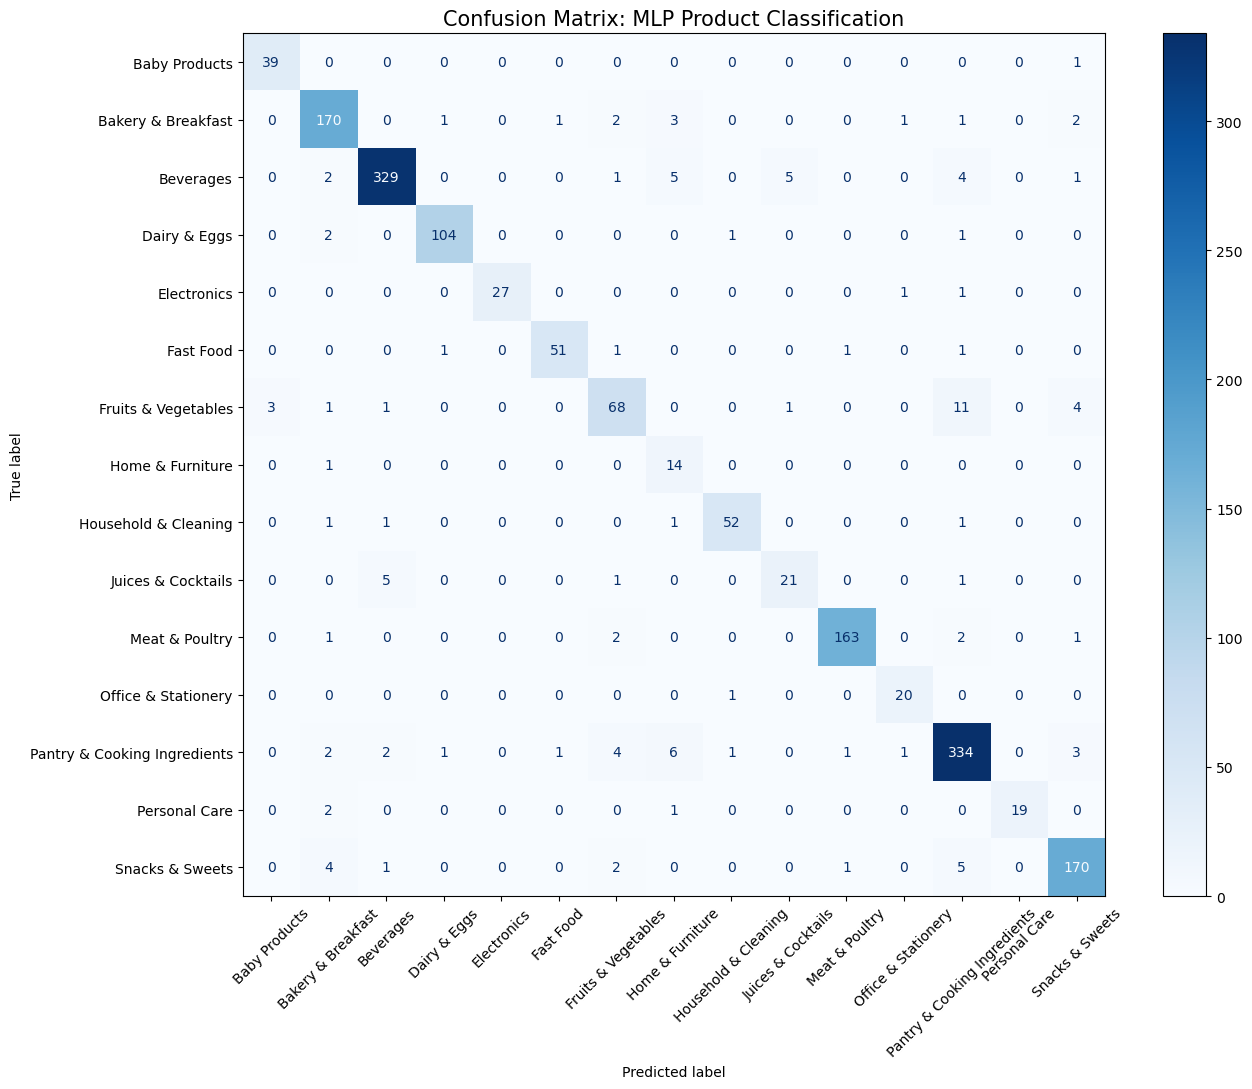

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

mlp_model = MLPClassifier(
    activation='relu', 
    learning_rate='constant', 
    early_stopping=True, 
    alpha=0.01, 
    max_iter=300,
    random_state=42
)

y_train_indices = np.argmax(y_train_resampled, axis=1)
mlp_model.fit(X_train_resampled, y_train_indices)

y_train_pred = mlp_model.predict(X_train_resampled)
y_val_pred = mlp_model.predict(X_val_tfidf)
y_test_pred = mlp_model.predict(X_test_tfidf)

y_val_indices = np.argmax(y_val, axis=1)
y_test_indices = np.argmax(y_test, axis=1)

train_acc = accuracy_score(y_train_indices, y_train_pred)
val_acc = accuracy_score(y_val_indices, y_val_pred)
test_acc = accuracy_score(y_test_indices, y_test_pred)

print(f"MLP Accuracy (Train): {train_acc:.3f}")
print(f"MLP Accuracy (Validation): {val_acc:.3f}")
print(f"MLP Accuracy (Test): {test_acc:.3f}")

raw_categories = encoder.categories_[0]

categories = [str(cls) if str(cls) != 'nan' else 'Others' for cls in raw_categories]

fig, ax = plt.subplots(figsize=(14, 11))
cm = confusion_matrix(y_test_indices, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=categories)

disp.plot(cmap='Blues', values_format='d', ax=ax, xticks_rotation=45)

plt.title('Confusion Matrix: MLP Product Classification', fontsize=15)
plt.tight_layout()
plt.show()

In [61]:
from sklearn.metrics import classification_report

report = classification_report(y_test_indices, y_test_pred, target_names=categories)

print("Detailed Classification Report (MLP):")
print(report)

report_dict = classification_report(y_test_indices, y_test_pred, target_names=categories, output_dict=True)

pantry_precision = report_dict['Pantry & Cooking Ingredients']['precision']
print(f"\nPrecision for Pantry: {pantry_precision:.2f}")

Detailed Classification Report (MLP):
                              precision    recall  f1-score   support

               Baby Products       0.93      0.97      0.95        40
          Bakery & Breakfast       0.91      0.94      0.93       181
                   Beverages       0.97      0.95      0.96       347
                Dairy & Eggs       0.97      0.96      0.97       108
                 Electronics       1.00      0.93      0.96        29
                   Fast Food       0.96      0.93      0.94        55
         Fruits & Vegetables       0.84      0.76      0.80        89
            Home & Furniture       0.47      0.93      0.62        15
        Household & Cleaning       0.95      0.93      0.94        56
          Juices & Cocktails       0.78      0.75      0.76        28
              Meat & Poultry       0.98      0.96      0.97       169
         Office & Stationery       0.87      0.95      0.91        21
Pantry & Cooking Ingredients       0.92      0.94  

# KNeighbors تدريب مودل 

In [85]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(
    n_neighbors=11,
    weights='distance',
    metric='cosine',
)

y_train_indices = np.argmax(y_train_resampled, axis=1)

knn_model.fit(X_train_resampled, y_train_indices)

y_train_pred_knn = knn_model.predict(X_train_resampled)
y_val_pred_knn = knn_model.predict(X_val_tfidf)
y_test_pred_knn = knn_model.predict(X_test_tfidf)

train_acc_knn = accuracy_score(y_train_indices, y_train_pred_knn)
val_acc_knn = accuracy_score(np.argmax(y_val, axis=1), y_val_pred_knn)
test_acc_knn = accuracy_score(np.argmax(y_test, axis=1), y_test_pred_knn)

print(f"KNN Accuracy (Train): {train_acc_knn:.3f}")
print(f"KNN Accuracy (Validation): {val_acc_knn:.3f}")
print(f"KNN Accuracy (Test): {test_acc_knn:.3f}")

KNN Accuracy (Train): 1.000
KNN Accuracy (Validation): 0.834
KNN Accuracy (Test): 0.828


# RandomForest تدريب مودل 

In [105]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import numpy as np

rf_model = RandomForestClassifier(
    n_estimators=500,          
    max_depth=None,            
    min_samples_split=2,       
    min_samples_leaf=1,        
    max_features='sqrt',       
    class_weight='balanced',   
    random_state=42,
    n_jobs=-1
)

y_train_indices = np.argmax(y_train_resampled, axis=1)
y_test_indices = np.argmax(y_test, axis=1)

rf_model.fit(X_train_resampled, y_train_indices)

y_train_pred_rf = rf_model.predict(X_train_resampled)
y_val_pred_rf = rf_model.predict(X_val_tfidf)
y_test_pred_rf = rf_model.predict(X_test_tfidf)

train_acc_rf = accuracy_score(y_train_indices, y_train_pred_rf)
val_acc_rf = accuracy_score(np.argmax(y_val, axis=1), y_val_pred_rf)
test_acc_rf = accuracy_score(y_test_indices, y_test_pred_rf)

precision_rf, recall_rf, f1_rf, _ = precision_recall_fscore_support(
    y_test_indices, 
    y_test_pred_rf, 
    average='weighted'
)

print(f"--- Random Forest Performance ---")
print(f"Accuracy (Train): {train_acc_rf:.3f}")
print(f"Accuracy (Validation): {val_acc_rf:.3f}")
print(f"Accuracy (Test): {test_acc_rf:.3f}")
print(f"Weighted F1-Score (Test): {f1_rf:.3f}")

--- Random Forest Performance ---
Accuracy (Train): 1.000
Accuracy (Validation): 0.866
Accuracy (Test): 0.879
Weighted F1-Score (Test): 0.879


# MLP تقييم مودل 

# تقييم الموديلات

In [ ]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def get_model_summary(y_true, y_pred, model_name):
    if len(y_true.shape) > 1:
        y_true = np.argmax(y_true, axis=1)
    
    # حساب الدقة الكلية
    acc = accuracy_score(y_true, y_pred)
    
    # حساب المتوسط المرجح للـ Precision, Recall, F1

    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
    
    return {
        "Model": model_name,
        "Accuracy": f"{acc:.3f}",
        "Precision": f"{prec:.3f}",
        "Recall": f"{rec:.3f}",
        "F1-Score": f"{f1:.3f}"
    }

mlp_summary = get_model_summary(y_test, y_test_pred, "MLP (Proposed)")
# xgb_summary = get_model_summary(y_test, y_xgb_pred, "XGBoost")

print(mlp_summary)

{'Model': 'MLP (Proposed)', 'Accuracy': '0.931', 'Precision': '0.935', 'Recall': '0.931', 'F1-Score': '0.932'}


In [ ]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import numpy as np

# 1. التنبؤ باستخدام الموديل
y_test_pred_svm = svm_model.predict(X_test_tfidf)

# 2. تجهيز البيانات الحقيقية
y_test_true_indices = np.argmax(y_test, axis=1)

# 3. حساب المقاييس المرجحة
precision_svm, recall_svm, f1_svm, _ = precision_recall_fscore_support(
    y_test_true_indices, 
    y_test_pred_svm, 
    average='weighted'
)

# 4. حساب الدقة الكلية
accuracy_svm = accuracy_score(y_test_true_indices, y_test_pred_svm)

# 5. عرض النتائج النهائية للموديل
svm_metrics_summary = {
    'Model': 'SVM (OneVsRestClassifier)',
    'Accuracy': f'{accuracy_svm:.3f}',
    'Precision': f'{precision_svm:.3f}',
    'Recall': f'{recall_svm:.3f}',
    'F1-Score': f'{f1_svm:.3f}'
}

print("--- Final Evaluation for svm_model ---")
print(svm_metrics_summary)

--- Final Evaluation for svm_model ---
{'Model': 'SVM (OneVsRestClassifier)', 'Accuracy': '0.929', 'Precision': '0.937', 'Recall': '0.929', 'F1-Score': '0.932'}


In [ ]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import numpy as np

# 1. التنبؤ باستخدام الموديل
y_test_pred = rf_model.predict(X_test_tfidf) 

# 2. تجهيز البيانات الحقيقية
y_test_true_indices = np.argmax(y_test, axis=1)

# 3. حساب المقاييس المرجحة
precision, recall, f1, _ = precision_recall_fscore_support(
    y_test_true_indices, 
    y_test_pred, 
    average='weighted'
)

# 4. حساب الدقة الكلية
accuracy = accuracy_score(y_test_true_indices, y_test_pred)

# 5. عرض النتائج النهائية 
rf_metrics_summary = {
    'Model': 'Random Forest (Final)', 
    'Accuracy': f'{accuracy:.3f}',
    'Precision': f'{precision:.3f}',
    'Recall': f'{recall:.3f}',
    'F1-Score': f'{f1:.3f}'
}

print("--- Final Evaluation Results ---")
print(rf_metrics_summary)

--- Final Evaluation Results ---
{'Model': 'Random Forest (Final)', 'Accuracy': '0.879', 'Precision': '0.884', 'Recall': '0.879', 'F1-Score': '0.879'}


In [ ]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import numpy as np

# 1. التنبؤ باستخدام موديل الـ KNN
y_test_pred_knn = knn_model.predict(X_test_tfidf)

# 2. تجهيز البيانات  للمقارنة
y_test_true_indices = np.argmax(y_test, axis=1)

# 3. حساب المقاييس المرجحة (Weighted Metrics)
precision_knn, recall_knn, f1_knn, _ = precision_recall_fscore_support(
    y_test_true_indices, 
    y_test_pred_knn, 
    average='weighted'
)

# 4. حساب الدقة الكلية
accuracy_knn = accuracy_score(y_test_true_indices, y_test_pred_knn)

# 5. عرض النتائج النهائية 
knn_metrics_summary = {
    'Model': 'K-Nearest Neighbors (k=11)',
    'Accuracy': f'{accuracy_knn:.3f}',
    'Precision': f'{precision_knn:.3f}',
    'Recall': f'{recall_knn:.3f}',
    'F1-Score': f'{f1_knn:.3f}'
}

print("--- Final Evaluation for KNN Model ---")
print(knn_metrics_summary)

--- Final Evaluation for KNN Model ---
{'Model': 'K-Nearest Neighbors (k=11)', 'Accuracy': '0.828', 'Precision': '0.864', 'Recall': '0.828', 'F1-Score': '0.837'}


# تجربه المودل المستهدف وحفظه

In [ ]:
new_item = ["FRENCH FRIES SH"]
new_item = ["عصير مانجو جهينة 1 لتر"]
new_item = ["خبز توست أبيض"]
new_item = ["صلصة طماطم هاينز"]
new_item = ["منظف زجاج بخاخ"]
new_item = ["شاي بلكونه"]
new_item = ["مارشميلو"]
new_item = ["مارشميلو فانيليا"]
new_item = ["مياة طبيعية صغيرة"]
new_item = ["مكس فاخر"]
new_item = ["بطيخ"]
new_item = ["جالون مياه"]
new_item = ["سكر"]
new_item = ["بيبسي لالتر ميكسات"]
new_item = ["لعبه هالي ميل ولد"]
new_item = ["قهوة تركي سينجل"]
new_item = ["ارز بالجمبري وسط"]
new_item = ["شيبسي عائلي ملح"]
new_item = ["بطاطس مقلية"]
new_item = ["بيض مسلوق"]
new_item = ["وجبة شاورما"]
new_item = ["عصير برتقال"]
new_item = ["كوكتيل شقف"]
new_item = ["عصير ليمون نعناع"]
new_item = ["كوكتيل مخلوط"]
new_item = ["عصير فيمتو"]
new_item = ["حليب بالزنجبيل"]
new_item = [" دجاج مشوي 1 مع ثوم"]
new_item = ["عصير ميكس 1 لنر"]
new_item = ["ريد بول"]
new_item = ["سلطة مشكل"]

# 1. تحويل النص الجديد إلى تمثيل TF-IDF باستخدام نفس المحول الذي تم تدريبه على بيانات التدريب
new_item_tfidf = tfidf.transform(new_item)

# 2. الحصول على احتمالات الفئات
probabilities = mlp_model.predict_proba(new_item_tfidf)[0]

# 3. ترتيب الفئات من الأعلى احتمالاً إلى الأقل (أخذ أفضل 5)
top_indices = np.argsort(probabilities)[::-1][:5] 

# 4. استخراج أسماء الفئات من المحول 

try:
    class_names = encoder.classes_
except AttributeError:
    class_names = encoder.categories_[0]

print(f"تحليل الشبكة العصبية (MLP) للمنتج '{new_item[0]}':")
print("-" * 40)
for idx in top_indices:
    name = class_names[idx]
    prob = probabilities[idx]
    print(f"• فئة [{name: <25}] | الثقة: {prob*100:.2f}%")

تحليل الشبكة العصبية (MLP) للمنتج 'سلطة مشكل':
----------------------------------------
• فئة [Fast Food                ] | الثقة: 88.56%
• فئة [Fruits & Vegetables      ] | الثقة: 7.61%
• فئة [Bakery & Breakfast       ] | الثقة: 1.44%
• فئة [Snacks & Sweets          ] | الثقة: 0.70%
• فئة [Pantry & Cooking Ingredients] | الثقة: 0.52%


In [111]:
import joblib

# تجميع كل الأدوات في قاموس واحد
MLP_Model = {
    'model': mlp_model,
    'tfidf': tfidf,
    'encoder': encoder
}

# حفظ القاموس بالكامل في ملف واحد
joblib.dump(MLP_Model, 'MLP_Model.joblib')

print("تم حفظ (النموذج + المحول + المشفر) في ملف واحد بنجاح!")

تم حفظ (النموذج + المحول + المشفر) في ملف واحد بنجاح!
